In [1]:
import torch
import os
import matplotlib.pyplot as plt
from monai.metrics import DiceMetric, compute_dice
from monai.transforms import (
    Activations,
    AsDiscrete,
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    Rotate90d,
    RemoveSmallObjectsd,
    ClipIntensityPercentilesd,
    ScaleIntensityd,
    OneOf,
)
from monai.data import decollate_batch
from src.model import sam_model_registry
import numpy as np
from typing import Optional
from src.utils import (
    prepare_sam_training_input,
    # prepare_sam_val_input_cp_only,
    prepare_sam_val_input_pp_only,
    prepare_sam_val_input_bb_only,
)
from dataclasses import dataclass

from src.utils import apply_coords_torch, apply_coords_bbox

np.set_printoptions(formatter={"float": "{: 0.3f}".format}, suppress=True)

from monai.transforms.utils import generate_spatial_bounding_box, get_extreme_points

/home/iscarinci/micromamba/envs/sam/lib/python3.10/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/iscarinci/micromamba/envs/sam/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def show_anns(
    masks, input_point, input_box, input_label, filename, image
):
    if len(masks) == 0:
        return

    for i, mask in enumerate(masks):
        plt.figure(figsize=(10, 10))
        plt.imshow(image, cmap="gray")
        show_mask(mask, plt.gca())
        if input_box is not None:
            show_box(input_box, plt.gca())
        if (input_point is not None) and (input_label is not None):
            show_points(input_point, input_label, plt.gca())

        plt.axis("off")
#        plt.savefig(
#            filename + "_" + str(i) + ".png", bbox_inches="tight", pad_inches=-0.1
#        )
        plt.show()
        plt.close()


def show_mask(mask, ax, random_color=True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(
        pos_points[:, 1],
        pos_points[:, 0],
        color="green",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )
    ax.scatter(
        neg_points[:, 1],
        neg_points[:, 0],
        color="red",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )
    


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(
        plt.Rectangle((x0, y0), w, h, edgecolor="green", facecolor=(0, 0, 0, 0), lw=2)
    )

In [112]:
checkpoint = './runs/tiny_prueba/model_best.pt'

In [113]:
model = sam_model_registry['tiny_vit'](
    checkpoint=None,
    image_size=1024,
    encoder_in_chans=27,
    mod='sam'
)

In [114]:
model_state = torch.load(checkpoint, map_location="cpu")

In [115]:
model_state = torch.load(checkpoint, map_location="cpu")["state_dict"]
model.load_state_dict(model_state)

<All keys matched successfully>

In [116]:
post_label = AsDiscrete(to_onehot=115)
post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])
dice_score = DiceMetric(include_background=False, reduction='mean', get_not_nans=False,return_with_label=False)

In [117]:
imagen_1 = [
    {
        "image": "/home/iscarinci/total_liifa/imagesTs/s0013.nii.gz",
        "label": "/home/iscarinci/total_liifa/labelsTs/s0013.nii.gz",
    } #
]
imagen_2 = [
    {
        "image": "../../../total_liifa/imagesTr/s0140.nii.gz",
        "label": "../../../total_liifa/labelsTr/s0140.nii.gz",
    } #10
]
imagen_3 = [
    {
        "image": "../../../total_liifa/imagesTr/s0500.nii.gz",
        "label": "../../../total_liifa/labelsTr/s0500.nii.gz",
    } #110
]

In [118]:
test_transform = Compose(
    [
        LoadImaged(keys=["image", "label"], image_only=True),
        EnsureChannelFirstd(keys=["image", "label"]),
        Orientationd(keys=["image", "label"], axcodes="RAI"),
        #Rotate90d(keys=["image", "label"], k=1),
#        Spacingd(
#            keys=["image", "label"],
#            pixdim=(1, 1, 1),
#            mode=("bilinear", "nearest"),
#            lazy=False,
#        ),
         ClipIntensityPercentilesd(keys=["image"], lower=0.5, upper=99.5),
         ScaleIntensityd(
            keys=["image"], minv=0.0, maxv=1.0
         ),
        #ScaleIntensityRanged(
        #    keys=["image"], a_min=-1024, a_max=1024, b_min=0.0, b_max=1.0, clip=True
        # ),
        RemoveSmallObjectsd(
            keys=["label"],
            min_size=100,
            connectivity=8,
        ),
#        OneOf(transforms=[
#            Rotate90d(keys=["image", "label"], k=0),
#            Rotate90d(keys=["image", "label"], k=1,spatial_axes=(0,2)),
#            Rotate90d(keys=["image", "label"], k=1,spatial_axes=(1,2)),
#        ])
    ]
)

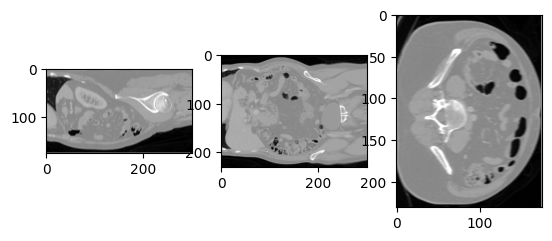

In [119]:
data = test_transform(imagen_1[0])
imagen, label = data["image"], data["label"]
fig, ax = plt.subplots(1, 3)
ax[0].imshow(imagen[0, 65, :, :], cmap="gray")
ax[1].imshow(imagen[0, :, 100, :], cmap="gray")
ax[2].imshow(imagen[0, :, :, 150], cmap="gray")

# plt.colorbar()

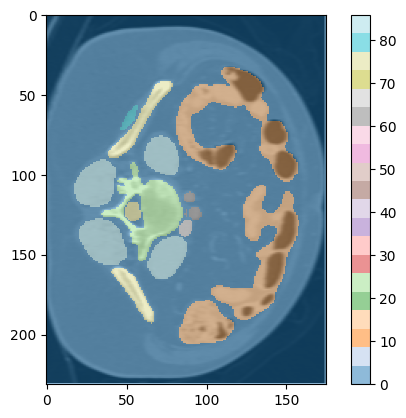

In [120]:
plt.imshow(imagen[0, :, :, 150], cmap="gray")
plt.pcolormesh(label[0, :, :, 150], alpha=0.5, cmap='tab20')
plt.colorbar()

In [121]:

liifa_labels = {
            0: "background",
            1: "spleen",
            2: "kidney_right",
            3: "kidney_left",
            4: "gallbladder",
            5: "liver",
            6: "stomach",
            7: "pancreas",
            8: "adrenal_gland_right",
            9: "adrenal_gland_left",
            10: "lung_left",
            11: "lung_right",
            12: "esophagus",
            13: "trachea",
            14: "thyroid_gland",
            15: "small_bowel",
            16: "duodenum",
            17: "colon",
            18: "urinary_bladder",
            19: "prostate",
            20: "kidney_cyst_left",
            21: "kidney_cyst_right",
            22: "sacrum",
            23: "vertebrae",
            24: "heart",
            25: "humerus_left",
            26: "humerus_right",
            27: "scapula_left",
            28: "scapula_right",
            29: "clavicula_left",
            30: "clavicula_right",
            31: "femur_left",
            32: "femur_right",
            33: "hip_left",
            34: "hip_right",
            35: "spinal_cord",
            36: "brain",
            37: "skull",
            38: "ribs",
        }

In [122]:
@dataclass
class config:
    max_points: int
    skip_bk: bool
    num_prompt: int
    distributed: bool
    label_prompt: bool
    bbox_prompt: bool
    point_prompt: bool

In [123]:
config = config(max_points=5, skip_bk=True, num_prompt=2, distributed=False, label_prompt=False, bbox_prompt=True, point_prompt=True)

In [124]:
def prepare_data(imagen, label, slice):
    imagen = imagen.squeeze()
    label = label.squeeze()
    imagen = imagen[..., slice - 9 //2 : slice + 9 // 2 + 1].permute(2, 0, 1)
    label = label[..., slice - 9 //2 : slice + 9 // 2 + 1][..., 9 // 2]
    return imagen, label

In [125]:
def inference(
    image,
    labels,
    model,
    prompt: str = "point",
    config=None,
    n_point: int = 1,
):
    model.eval()
    with torch.no_grad():
        if prompt == "point":
            data, target, _ = prepare_sam_val_input_pp_only(
                image, labels, config, 1024, n_point, 1
            )
        elif prompt == "bbox":
            data, target, _ = prepare_sam_val_input_bb_only(image, labels)
        
        with torch.cuda.amp.autocast():
            output = model(data)

        output = torch.argmax(post_pred(output[0]['high_res_logits']),dim=0)
        #output = post_pred(output[0]["high_res_logits"])
        return output, data

In [126]:
image_i, label_i = prepare_data(imagen, label, 65)

In [127]:
imagen.shape

torch.Size([1, 231, 175, 301])

In [128]:
prueba, data = inference(image=image_i, labels=label_i, model=model, config=config, prompt='bbox', n_point=9) 

In [129]:
prueba = torch.where(prueba > 0, prueba+1, 0)

In [130]:
y_pred = post_label(prueba)
y = post_label(label_i.unsqueeze(0))

In [131]:
y_pred.shape

torch.Size([115, 231, 175])

In [132]:
np.where(y_pred==1)

(array([  0,   0,   0, ..., 114, 114, 114]),
 array([  0,   0,   0, ..., 136, 139, 140]),
 array([  0,   1,   2, ..., 139, 136, 136]))

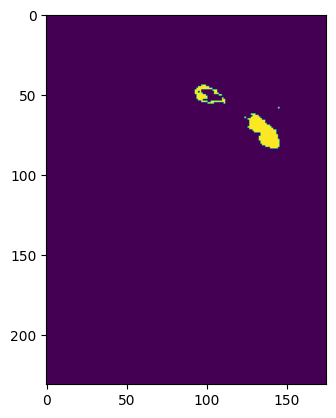

In [133]:
plt.imshow(y_pred[17, :, :])

In [134]:
acc_batch=compute_dice(y_pred.unsqueeze(0),y.unsqueeze(0))

In [135]:
acc_batch

metatensor([[0.8941, 0.0000, 0.7268, 0.7618,    nan, 0.7184, 0.8492, 0.0000, 0.0000,
         0.6667,    nan,    nan,    nan,    nan,    nan, 0.0000, 0.7039, 0.7423,
            nan,    nan, 0.0000,    nan,    nan,    nan,    nan,    nan,    nan,
            nan, 0.8142,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
            nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
            nan,    nan,    nan,    nan, 0.7500,    nan,    nan,    nan,    nan,
            nan,    nan,    nan,    nan,    nan,    nan, 0.5939, 0.4144,    nan,
            nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
            nan,    nan,    nan,    nan, 0.0000,    nan,    nan,    nan,    nan,
            nan,    nan, 0.6196, 0.6334, 0.0000, 0.6835,    nan,    nan,    nan,
            nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan, 0.3478,
         0.0000, 0.0000, 0.5412, 0.6667,    nan,    nan,    nan,    nan,    nan,
         0.0000, 0.0000,

In [136]:
acc_sum, not_nans = (
                        torch.nansum(acc_batch).item(),
                      115 - torch.sum(torch.isnan(acc_batch).float()).item(),
                    )

In [137]:
acc_sum/not_nans

0.36751281853878137

In [138]:
label_decollate = post_label(prueba)
label_in = post_label(label_in)
label_decollate.shape

NameError: name 'label_in' is not defined

In [139]:
dice_score(label_decollate, label_i)

IndexError: index 175 is out of bounds for dimension 1 with size 175

In [140]:
image_pre = model.preprocess(image_i)

In [141]:
apply_coords_bbox(data[0]["boxes"][34], 1024, 316)

tensor([16.4156, 19.1515, 27.3593, 30.0952])

In [142]:
np.unique(label_i)

array([ 0.000,  1.000,  2.000,  3.000,  5.000,  6.000,  7.000,  8.000,
        9.000,  15.000,  16.000,  17.000,  20.000,  28.000,  49.000,
        60.000,  61.000,  76.000,  83.000,  84.000,  85.000,  86.000,
        98.000,  99.000,  100.000,  101.000,  102.000,  108.000,  109.000,
        110.000,  111.000,  112.000,  114.000], dtype=float32)

In [143]:
np.unique(prueba)

array([  0,   2,   3,   5,   6,   7,   8,   9,  16,  17,  28,  49,  60,
        61,  83,  84,  86,  98, 101, 102, 111, 114])

In [144]:
prueba = np.where(prueba>1, prueba+1, prueba)

In [145]:
show_anns(
    prueba == 22,
    #apply_coords_torch(data[0]["point_coords"][37], 1024, 316),
    None,
    #apply_coords_bbox(data[0]["boxes"][1], 1024,316),
    #data[0]["point_labels"][22].numpy(),
    #None,
    None,
    None,
    image_i[9 // 2, ...].numpy(),
)

TypeError: show_anns() missing 1 required positional argument: 'image'

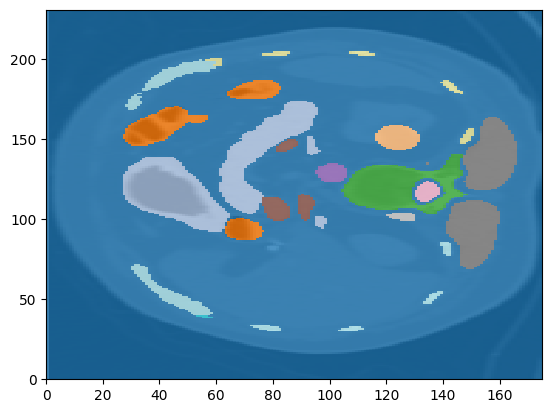

In [146]:
plt.pcolormesh(np.rot90(image_i[9//2,:, :].numpy(), k=2), cmap='gray')
plt.pcolormesh(np.rot90(label_i[:, :], k=2), alpha=0.8, cmap='tab20')

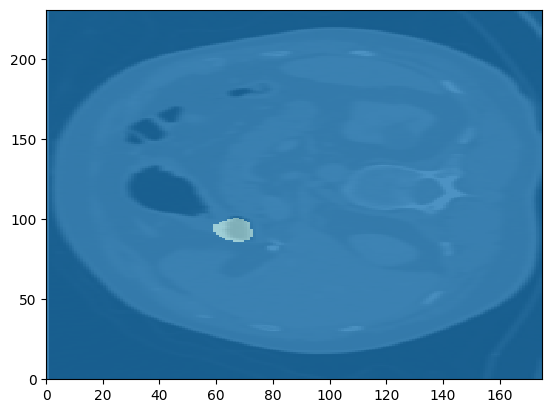

In [148]:
plt.pcolormesh(np.rot90(image_i[9 // 2, :, :].numpy(), k=-2), cmap="gray")
plt.pcolormesh(np.rot90(label_decollate[16,:,:], k=-2), alpha=0.8, cmap="tab20")

In [43]:
data, target, target_original, skip = prepare_sam_training_input(image_i, label_i, config, model, 1024, 0, 1)

In [170]:
data_process = model.preprocess(image_i, is_input=True)

In [171]:
label_process = model.preprocess(label_i[4,...], is_input=True)

In [42]:
label_process.shape

torch.Size([948, 1024, 1024])

ValueError: not enough values to unpack (expected 2, got 1)

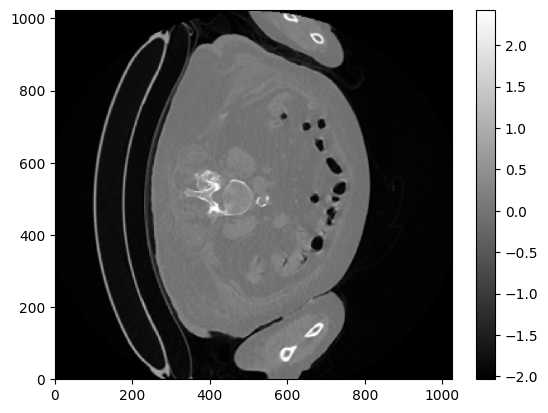

In [41]:
plt.pcolormesh(data_process[9 // 2, ...], cmap="gray")
plt.colorbar()
plt.pcolormesh(label_process[1, 0, ...], alpha=0.8, cmap="tab20")

In [149]:
label_i[...].shape

torch.Size([231, 175])

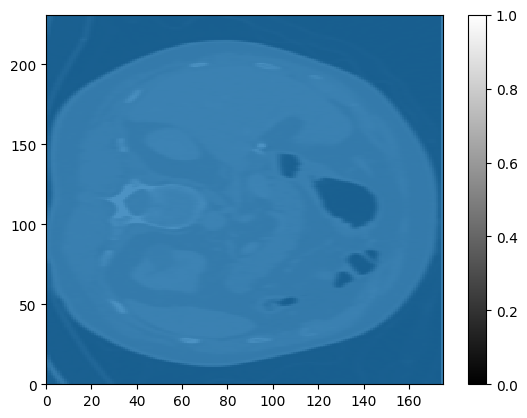

In [150]:
plt.pcolormesh(image_i[9 // 2, ...], cmap="gray")
plt.colorbar()
plt.pcolormesh(label_i[...] == 23, alpha=0.8, cmap="tab20")

NameError: name 'data_process' is not defined

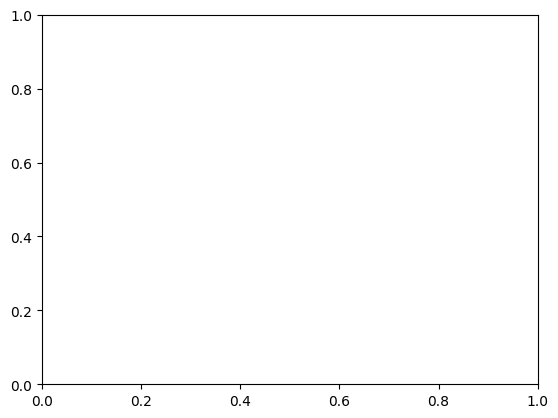

In [151]:
fig, ax = plt.subplots(1, 1)
ax.pcolormesh(data_process[9 // 2, ...], cmap="gray")
x0, y0 = data[0]['boxes'][22,1], data[0]['boxes'][22,0]
w, h = data[0]['boxes'][22,3] - data[0]['boxes'][22,1], data[0]['boxes'][22,2] - data[0]['boxes'][22,0]
ax.add_patch(
        plt.Rectangle((x0, y0), w, h, edgecolor="green", facecolor=(0, 0, 0, 0), lw=2)
    )

In [152]:
np.unique(label_i)

array([ 0.000,  1.000,  2.000,  3.000,  5.000,  6.000,  7.000,  8.000,
        9.000,  15.000,  16.000,  17.000,  20.000,  28.000,  49.000,
        60.000,  61.000,  76.000,  83.000,  84.000,  85.000,  86.000,
        98.000,  99.000,  100.000,  101.000,  102.000,  108.000,  109.000,
        110.000,  111.000,  112.000,  114.000], dtype=float32)

In [153]:
mask = label_i[...] == 5

In [154]:
active_px = torch.nonzero(mask.as_tensor())

In [155]:
active_px

tensor([[132, 141],
        [132, 142],
        [133,  84],
        ...,
        [198,  87],
        [198,  88],
        [198,  89]])

In [156]:
min_coord, _ = torch.min(active_px, dim=0)
max_coord, _ = torch.max(active_px, dim=0)


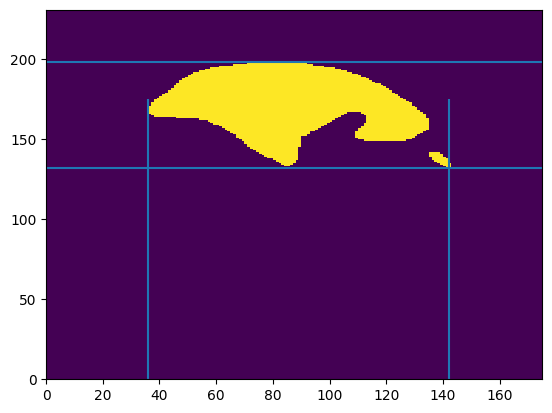

In [157]:
plt.pcolormesh(mask)
plt.hlines(min_coord[0].numpy(), 0, mask.shape[1])
plt.vlines(min_coord[1].numpy(), 0, mask.shape[1])
plt.hlines(max_coord[0].numpy(), 0, mask.shape[1])
plt.vlines(max_coord[1].numpy(), 0, mask.shape[1])

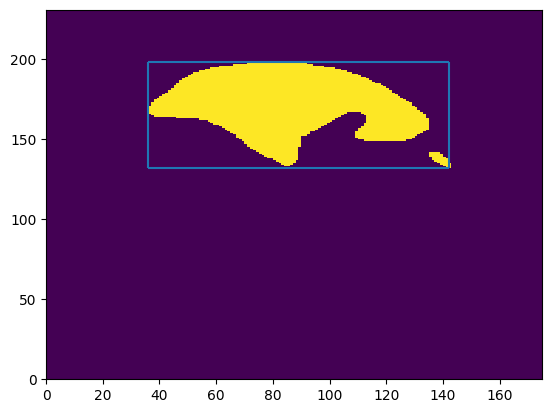

In [158]:
plt.pcolormesh(mask)
plt.hlines(min_coord[0].numpy(), min_coord[1], max_coord[1])
plt.vlines(min_coord[1].numpy(), min_coord[0], max_coord[0])
plt.hlines(max_coord[0].numpy(), min_coord[1], max_coord[1])
plt.vlines(max_coord[1].numpy(), min_coord[0], max_coord[0])

In [159]:
h_b, w_b = abs(max_coord[0] - min_coord[0]), abs(max_coord[1] - min_coord[1])

In [160]:
noise_std = min(h_b, w_b) * 0.1

In [161]:
noise_std

tensor(6.6000)

In [162]:
max_noise = min(15, int(noise_std * 15))

In [163]:
noise_x = torch.randint(low=-max_noise, high=max_noise, size=[1])
noise_y = torch.randint(low=-max_noise, high=max_noise, size=[1])

In [164]:
x0, y0 = min_coord[0] + noise_x, min_coord[1] + noise_y
x1, y1 = max_coord[0] + noise_x, max_coord[1] + noise_y

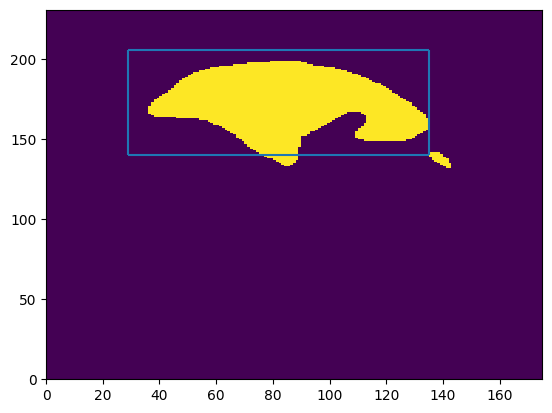

In [165]:
plt.pcolormesh(mask)
plt.hlines(x0.numpy(), y0, y1)
plt.vlines(y0.numpy(), x0, x1)
plt.hlines(x1.numpy(), y0, y1)
plt.vlines(y1.numpy(), x0, x1)

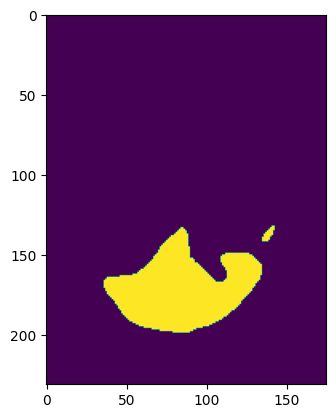

In [166]:
plt.imshow(mask)

In [167]:
(x0, y0), (x1, y1) = generate_spatial_bounding_box(mask.unsqueeze(dim=0), allow_smaller=False, margin=10)

In [168]:
label_i.shape

torch.Size([231, 175])

In [169]:
x0

122

NameError: name 'bbox' is not defined

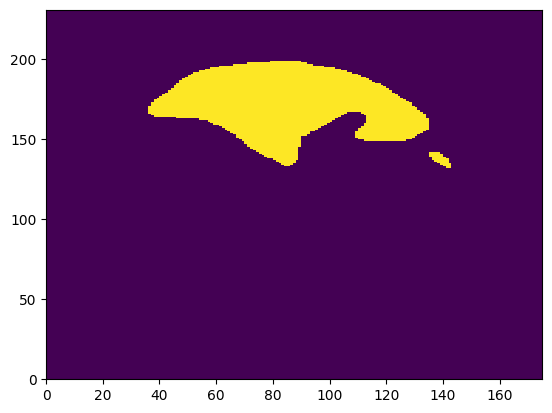

In [170]:
fig, ax = plt.subplots(1,1)
ax.pcolormesh(mask)
ax.add_patch(
        plt.Rectangle((bbox[0][1], bbox[0][0]), bbox[1][1]-bbox[0][1], bbox[1][0]-bbox[0][0] , edgecolor="green", facecolor=(0, 0, 0, 0), lw=2)
)

In [171]:
unique_labels = torch.tensor([i for i in range(1, 39)])

In [172]:
batch_labels = torch.stack(
        [label_i == unique_labels[i] for i in range(len(unique_labels))], dim=0
    ).float()

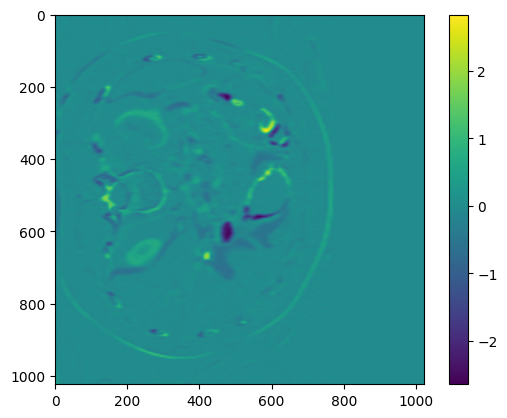

In [173]:
plt.imshow(image_pre[10, :, :]-image_pre[1, :, :])
plt.colorbar()

NameError: name 'image_pre_final' is not defined

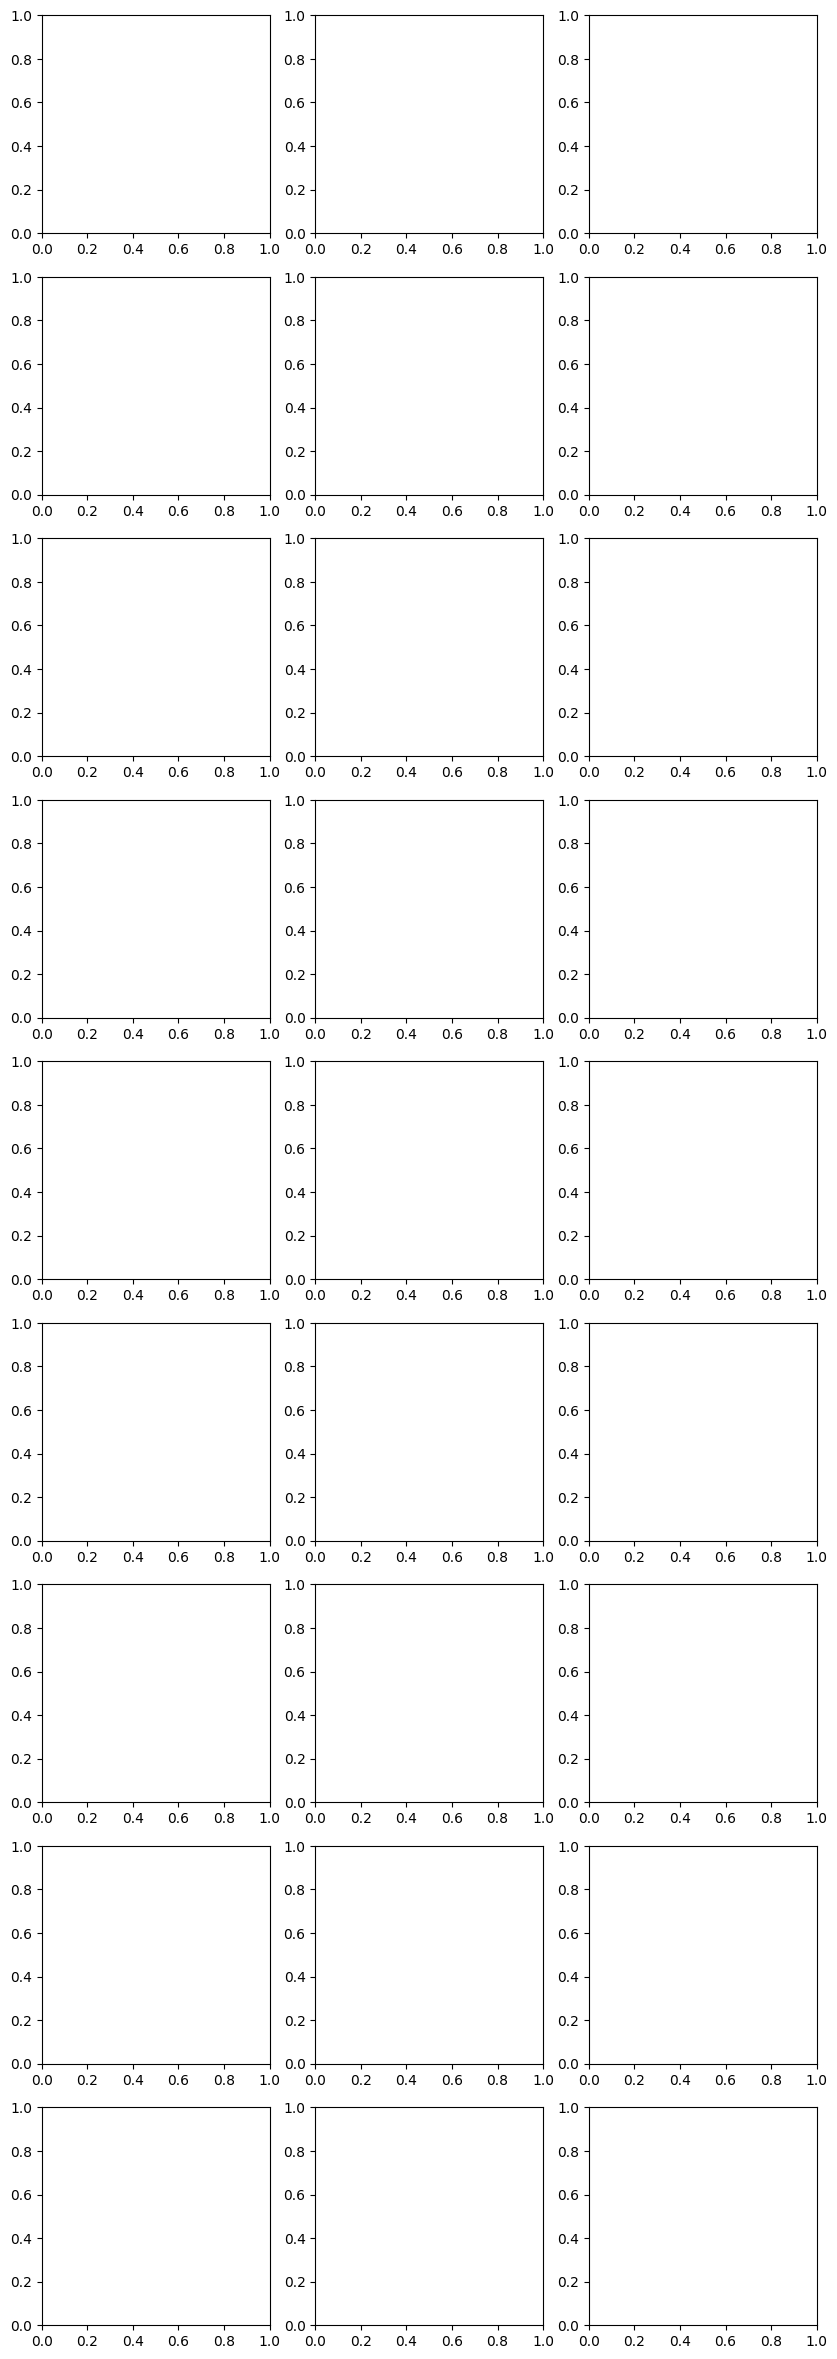

In [174]:
fig, ax = plt.subplots(9, 3, figsize=(10, 30))
for i in range(9):
    for j in range(3):
        img = ax[i, j].imshow(
            np.rot90(image_pre_final[i * 3 + j, :, :], k=1),
            vmax=torch.max(image_pre_final), vmin=torch.min(image_pre_final)
)
        ax[i, j].set_axis_off()
        plt.colorbar(mappable=img, ax=ax[i, j])

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
for i in range(3):
    img = ax[i].pcolormesh(np.rot90(image_pre_chunk[8][i,...], k=3))
    plt.colorbar(ax=ax[i], mappable=img)
    ax[i].set_axis_off()

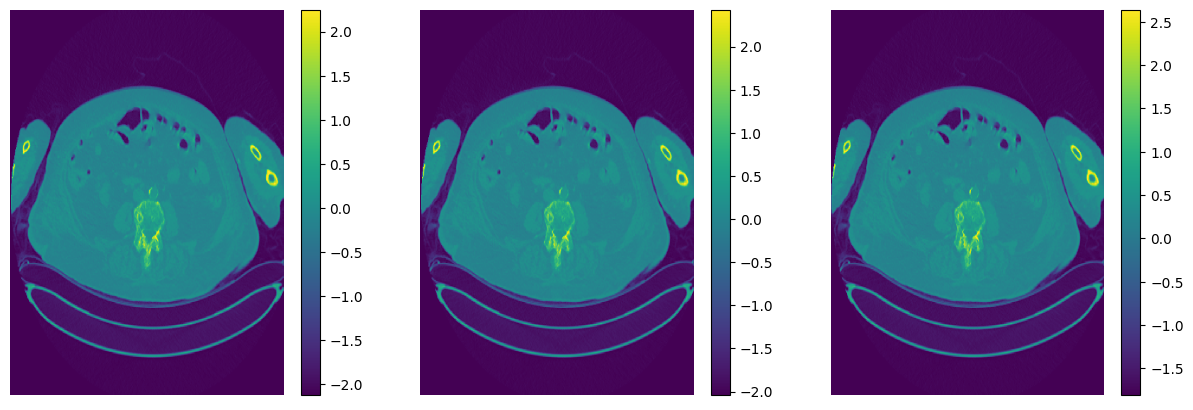

In [88]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    img = ax[i].pcolormesh(np.rot90(image_pre_chunk[0][i, ...], k=3))
    plt.colorbar(ax=ax[i], mappable=img)
    ax[i].set_axis_off()

In [105]:
image_pre_chunk = torch.chunk(image_pre, 9, dim=0)

In [112]:
image_pre_final = torch.stack(image_pre_chunk, dim=0)

In [113]:
image_pre_final.shape

torch.Size([9, 3, 1024, 1024])

In [108]:
from einops import rearrange

In [114]:
image_pre_final = rearrange(image_pre_final, 'b c h w -> (c b) h w')

In [117]:
torch.max(image_pre_final)


metatensor(2.6400)

In [137]:
def reor(tensor_ori):
    tensor_fin = torch.chunk(tensor_ori, tensor_ori.shape[0] // 3, dim=0)
    tensor_fin = torch.stack(tensor_fin, dim=0)
    return rearrange(tensor_fin, "b c h w -> (c b) h w")

In [129]:
image_reor = reor(image_pre)

In [138]:
image_reor_2 = reor(image_pre)

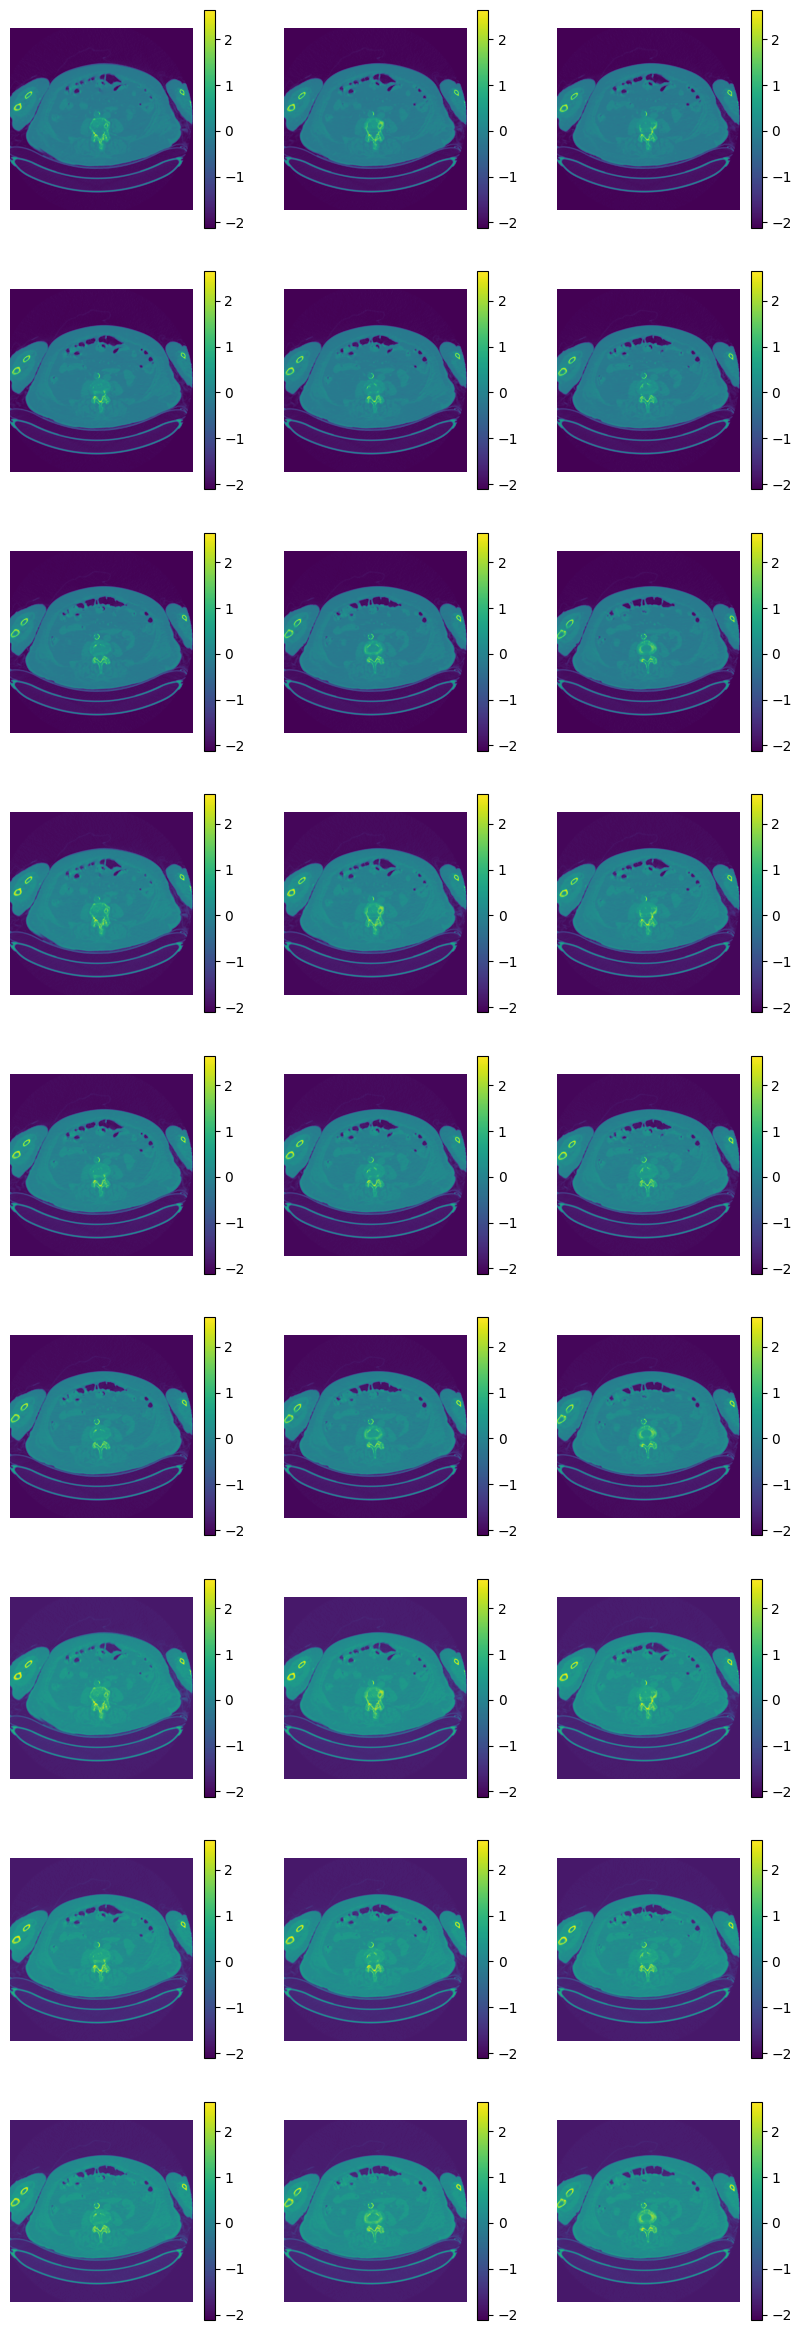

In [131]:
fig, ax = plt.subplots(9, 3, figsize=(10, 30))
for i in range(9):
    for j in range(3):
        img = ax[i, j].imshow(
            np.rot90(image_reor[i * 3 + j, :, :], k=1),
            vmax=torch.max(image_reor),
            vmin=torch.min(image_reor),
        )
        ax[i, j].set_axis_off()
        plt.colorbar(mappable=img, ax=ax[i, j])

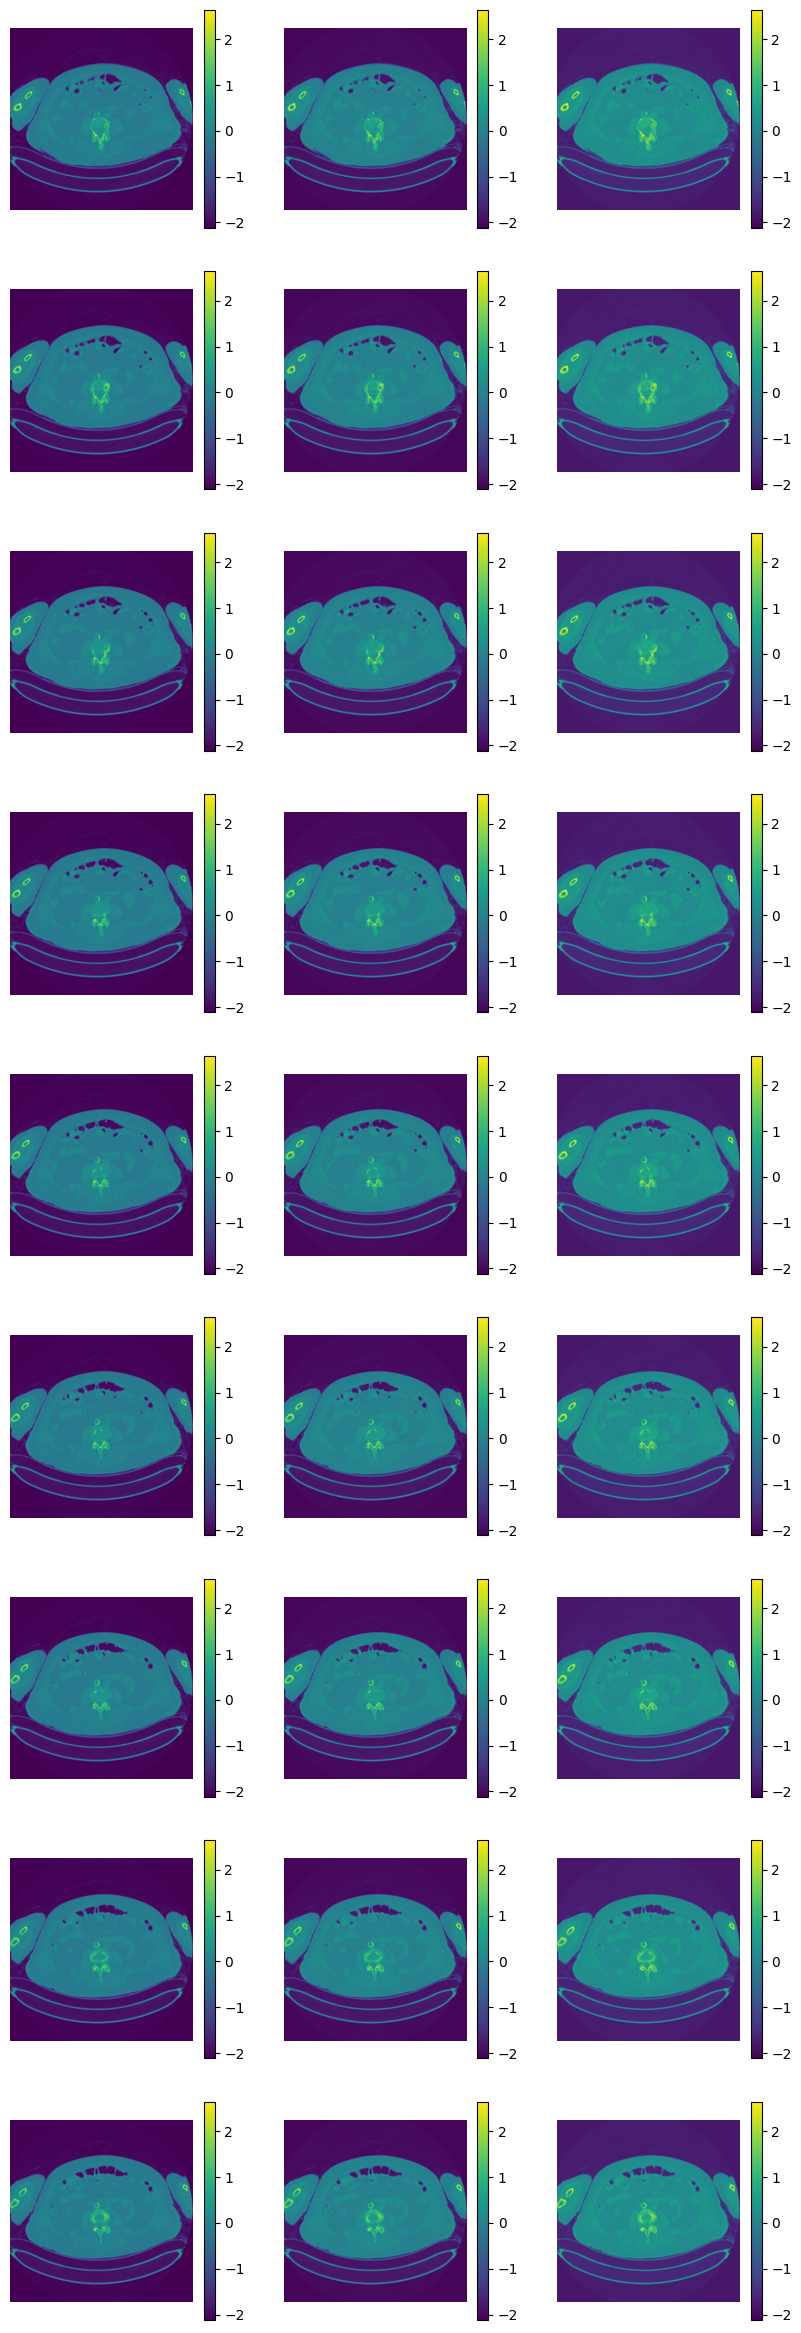

In [132]:
fig, ax = plt.subplots(9, 3, figsize=(10, 30))
for i in range(9):
    for j in range(3):
        img = ax[i, j].imshow(
            np.rot90(image_reor_2[i * 3 + j, :, :], k=1),
            vmax=torch.max(image_reor_2),
            vmin=torch.min(image_reor_2),
        )
        ax[i, j].set_axis_off()
        plt.colorbar(mappable=img, ax=ax[i, j])

In [168]:
state = torch.load("../../weight/mobile_sam.pt", map_location=torch.device("cpu"))

In [173]:
for k in state.keys():
    if 'mask_decoder' in k:
        print(k,'\n')


mask_decoder.transformer.layers.0.self_attn.q_proj.weight 

mask_decoder.transformer.layers.0.self_attn.q_proj.bias 

mask_decoder.transformer.layers.0.self_attn.k_proj.weight 

mask_decoder.transformer.layers.0.self_attn.k_proj.bias 

mask_decoder.transformer.layers.0.self_attn.v_proj.weight 

mask_decoder.transformer.layers.0.self_attn.v_proj.bias 

mask_decoder.transformer.layers.0.self_attn.out_proj.weight 

mask_decoder.transformer.layers.0.self_attn.out_proj.bias 

mask_decoder.transformer.layers.0.norm1.weight 

mask_decoder.transformer.layers.0.norm1.bias 

mask_decoder.transformer.layers.0.cross_attn_token_to_image.q_proj.weight 

mask_decoder.transformer.layers.0.cross_attn_token_to_image.q_proj.bias 

mask_decoder.transformer.layers.0.cross_attn_token_to_image.k_proj.weight 

mask_decoder.transformer.layers.0.cross_attn_token_to_image.k_proj.bias 

mask_decoder.transformer.layers.0.cross_attn_token_to_image.v_proj.weight 

mask_decoder.transformer.layers.0.cross_attn_token_t